# Analysis of Cafe sales

In this notebook we will do a EDA of cafe sales data!

## Dependecies

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Read in data

In [3]:
df = pd.read_csv("dirty_cafe_sales.csv")

## EDA

Initialy we have 10.000 row of data with 8 features and all of them are of object Dtype! Initialy we have 10.000 unique transactions.

In [4]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [6]:
df.shape

(10000, 8)

In [7]:
df["Transaction ID"].nunique()

10000

In [8]:
df[df.drop(columns=["Transaction ID"]).duplicated()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
675,TXN_2601689,Salad,4,5.0,20.0,Digital Wallet,Takeaway,2023-01-14
1367,TXN_5566652,Juice,5,3.0,15.0,Credit Card,NaN,2023-09-16
1521,TXN_6817795,Tea,1,1.5,1.5,Cash,Takeaway,2023-09-12
1949,TXN_8997048,Juice,1,3.0,3.0,NaN,In-store,2023-12-05
2454,TXN_2490185,Salad,4,5.0,20.0,Credit Card,In-store,2023-12-18
...,...,...,...,...,...,...,...,...
9898,TXN_8999360,Juice,3,3.0,9.0,Cash,Takeaway,2023-09-27
9909,TXN_2112522,Sandwich,5,4.0,20.0,Digital Wallet,Takeaway,2023-04-30
9930,TXN_4428252,Sandwich,3,4.0,12.0,NaN,Takeaway,2023-10-31
9967,TXN_8563793,Juice,4,3.0,12.0,NaN,In-store,2023-03-26


In [9]:
df_no_trans = df.drop(columns=["Transaction ID"])

In [10]:
df_no_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Item              9667 non-null   object
 1   Quantity          9862 non-null   object
 2   Price Per Unit    9821 non-null   object
 3   Total Spent       9827 non-null   object
 4   Payment Method    7421 non-null   object
 5   Location          6735 non-null   object
 6   Transaction Date  9841 non-null   object
dtypes: object(7)
memory usage: 547.0+ KB


In [11]:
df_no_trans.columns

Index(['Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method',
       'Location', 'Transaction Date'],
      dtype='object')

In [12]:
# df_no_trans["Quantity"] = df_no_trans["Quantity"].astype(dtype="int64", errors="ignore")
df_no_trans["Quantity"] = pd.to_numeric(df_no_trans["Quantity"], errors="coerce").astype("Int64")

In [13]:
# df_no_trans["Price Per Unit"] = df_no_trans["Price Per Unit"].astype(dtype="float64", errors="ignore")
df_no_trans["Price Per Unit"] = pd.to_numeric(df_no_trans["Price Per Unit"], errors="coerce").astype("Float64")

In [14]:
# df_no_trans["Total Spent"] = df_no_trans["Total Spent"].astype(dtype="float64", errors="ignore")
df_no_trans["Total Spent"] = pd.to_numeric(df_no_trans["Total Spent"], errors="coerce").astype("Float64")

In [15]:
df_no_trans["Transaction Date"] = pd.to_datetime(df_no_trans["Transaction Date"], format="%Y-%m-%d", errors="coerce")

In [16]:
df_no_trans.head()

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,Cookie,4,1.0,<NA>,Credit Card,In-store,2023-07-19
3,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [17]:
df_no_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Item              9667 non-null   object        
 1   Quantity          9521 non-null   Int64         
 2   Price Per Unit    9467 non-null   Float64       
 3   Total Spent       9498 non-null   Float64       
 4   Payment Method    7421 non-null   object        
 5   Location          6735 non-null   object        
 6   Transaction Date  9540 non-null   datetime64[ns]
dtypes: Float64(2), Int64(1), datetime64[ns](1), object(3)
memory usage: 576.3+ KB


In [18]:
## format="%Y%m%d", errors="coerce"

array([[<Axes: title={'center': 'Quantity'}>,
        <Axes: title={'center': 'Price Per Unit'}>],
       [<Axes: title={'center': 'Total Spent'}>,
        <Axes: title={'center': 'Transaction Date'}>]], dtype=object)

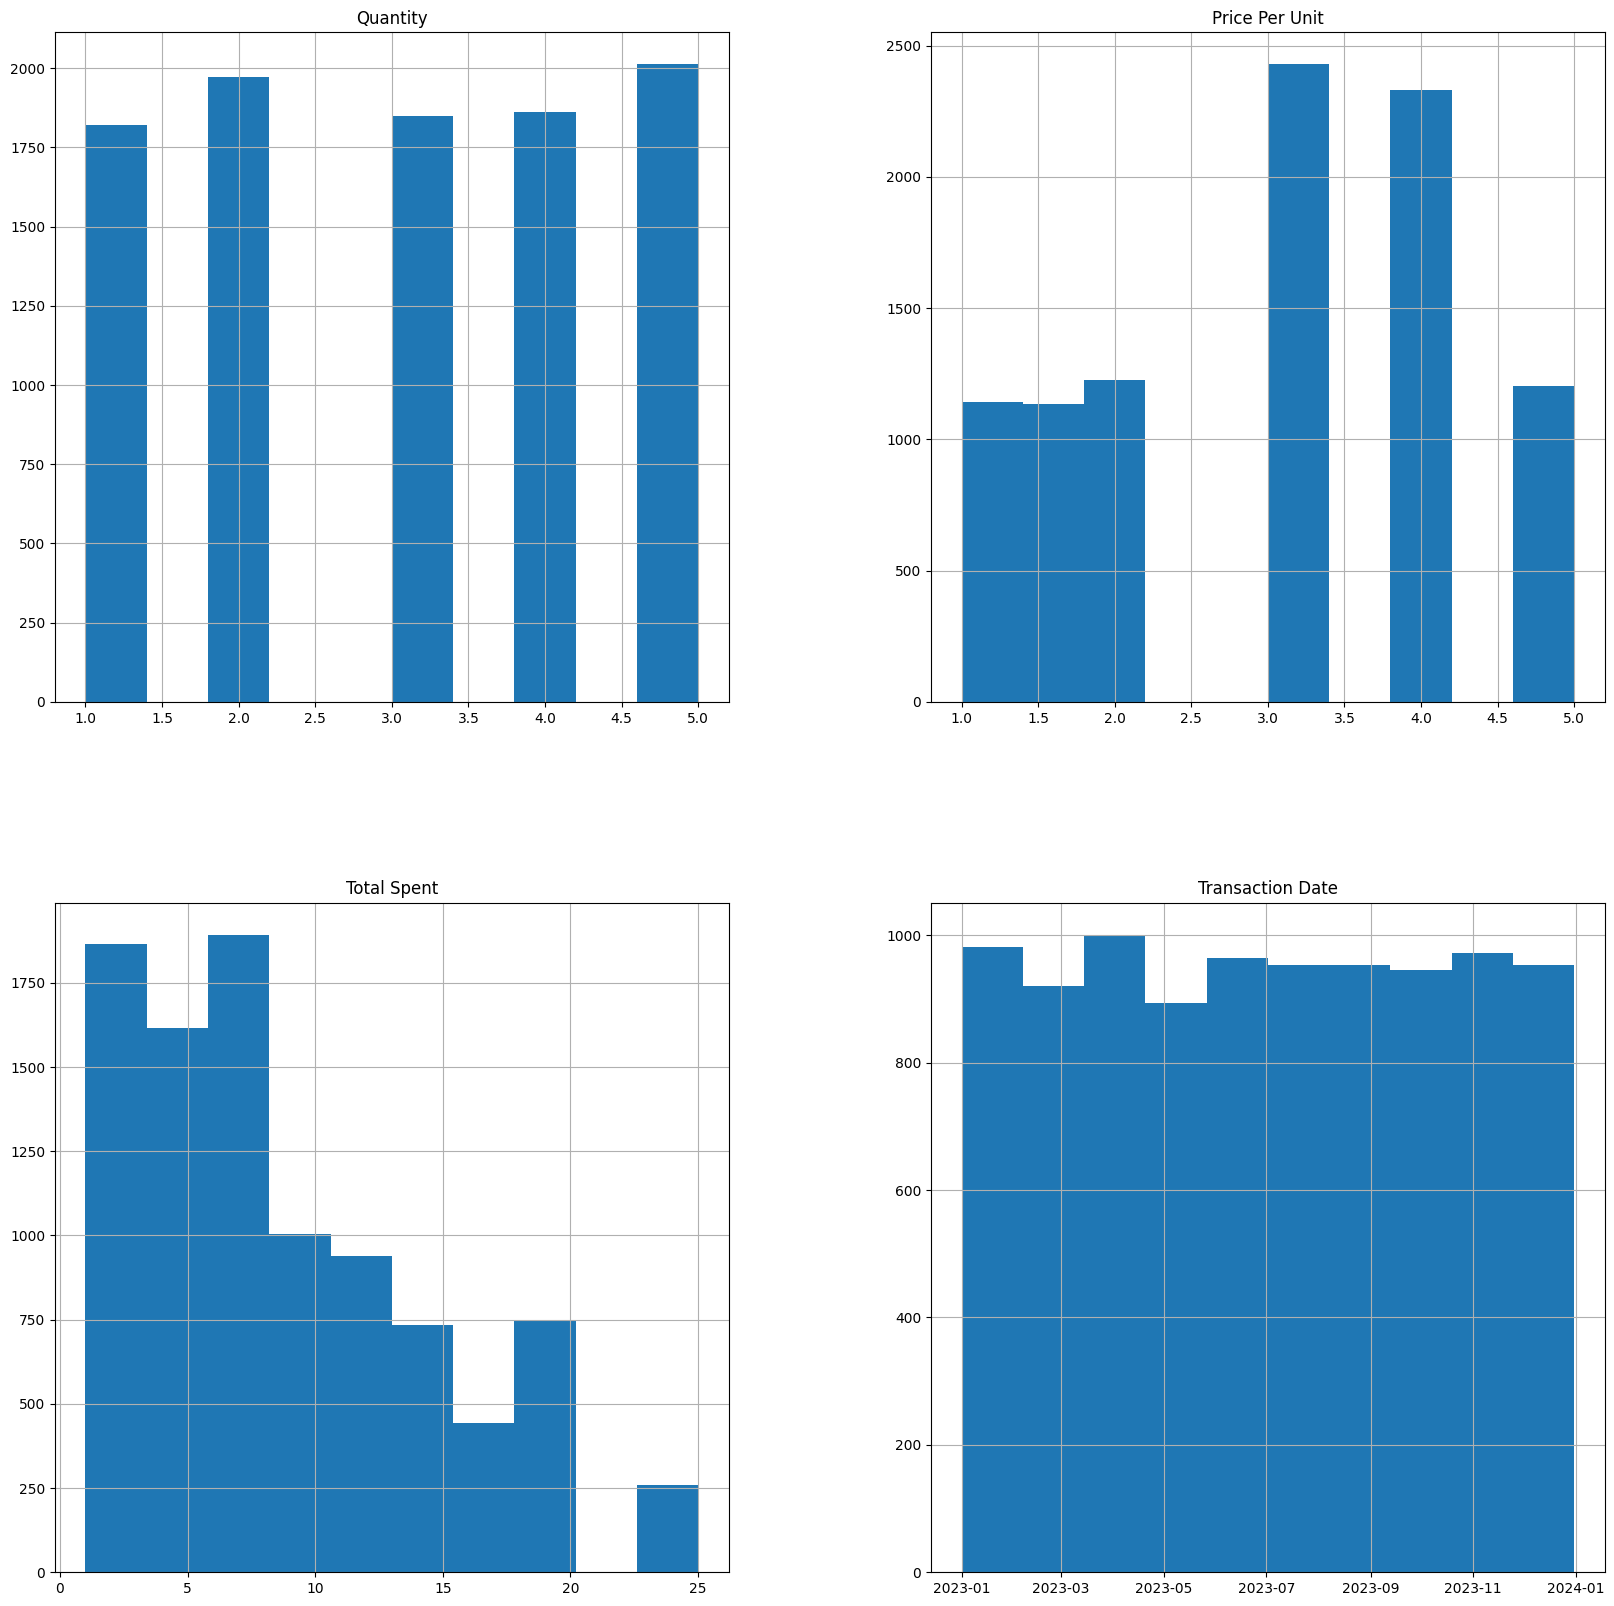

In [21]:
df_no_trans[['Quantity', 'Price Per Unit', 'Total Spent', 'Transaction Date']].hist(figsize=(20,20))